<a href="https://colab.research.google.com/github/FideliaOsei/cs666student/blob/main/Copy_of_CS666_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

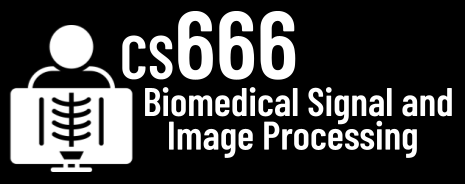
#Assignment 4

In [137]:
# NAME: Fidelia Darkoa Osei

In [138]:
# In this assignment, we will create a Random Forest classifier to detect pneumonia and covid in xrays!

In [139]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['f', 'clf']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [140]:
# we are using mahotas again, so lets install it!
!pip install mahotas

In [141]:
# our imports include sklearn this time
import mahotas as mh
import os
from sklearn.ensemble import RandomForestClassifier

**Task 1:** Download, extract, and load the data! [15 Points]

In [142]:
# Please download this file: https://cs666.org/data/xray/ with the wget command!
# Note: Please use the forwarded dropbox link and change dl=0 to dl=1!
# This is a subset of the Kaggle Pneumonia + Covid Datasets!

In [143]:
# Run this code to extract the zip file and to create
# the folder structure of normal/, pneumonia/, and covid/ images.
# Each folder contains the first images of the Kaggle datasets.
import zipfile
!wget "https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&dl=1" -O xray.zip
with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

NORMAL_DIR = 'normal/'
PNEUMONIA_DIR = 'pneumonia/'
COVID_DIR = 'covid/'

--2026-04-19 21:19:51--  https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.6.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc578c9df79a488e57f92ed87214.dl.dropboxusercontent.com/cd/0/inline/C-66WWJDexo5sAgxz0YccliDpMrHs9wxtDO5K71SZvRXVHWnHwjy4381UQoYs8CdSsN1MM3uS30HW0vtCOGfrSOC4Z0fqbi0_gdOAOA8lJ8YXN0BaEY20fMBJp8suz1NnDY/file?dl=1# [following]
--2026-04-19 21:19:52--  https://uc578c9df79a488e57f92ed87214.dl.dropboxusercontent.com/cd/0/inline/C-66WWJDexo5sAgxz0YccliDpMrHs9wxtDO5K71SZvRXVHWnHwjy4381UQoYs8CdSsN1MM3uS30HW0vtCOGfrSOC4Z0fqbi0_gdOAOA8lJ8YXN0BaEY20fMBJp8suz1NnDY/file?dl=1
Resolving uc578c9df79a488e57f92ed87214.dl.dropboxusercontent.com (uc578c9df79a488e57f92ed87214.dl.dropboxusercontent.com)... 162.125.6.15, 2620:100:601c:15::a27d:60f
Connecting

In [144]:
# Here we load the first image from the normal dataset.
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

In [145]:
# TODO: Please display this image and print the dimensions!

In [146]:
# TODO: YOUR CODE

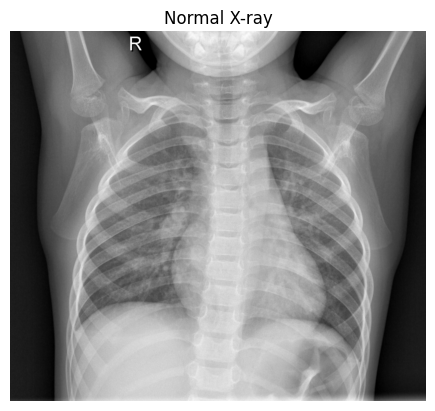

Image shape: (1858, 2090)


In [147]:
import matplotlib.pyplot as plt

# show image
plt.imshow(img, cmap='gray')
plt.title('Normal X-ray')
plt.axis('off')
plt.show()

# print dimensions
print("Image shape:", img.shape)

**Task 2:** Let's do some data wrangling and more visualization! [30 Points]

In [148]:
folders = [NORMAL_DIR, PNEUMONIA_DIR, COVID_DIR]
data = [[],[],[]]

for f_index,f in enumerate( folders ):
  all_files = os.listdir( f )

  data[f_index] = np.zeros( (len(all_files), 300, 300), dtype=np.float32)

  for i in range(len(all_files)):
    loaded_image = mh.imread( f + '/' + all_files[i] )
    if loaded_image.ndim > 2:
      loaded_image = mh.colors.rgb2gray(loaded_image[:,:,:3])

    loaded_image = mh.imresize( loaded_image, (300, 300) )
    img_shape = loaded_image.shape

    data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [149]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?
# Hint: The first two might be more obvious but the third one happens in the
# last line.
# TODO: Operation 1) YOUR ANSWER
# TODO: Operation 2) YOUR ANSWER
# TODO: Operation 3) YOUR ANSWER

Operation 1: Converting images to grayscale

Operation 2: Resizing images to a fixed size (300x300)

Operation 3: Organizing images into a structured dataset

In [150]:
# Now, let's look at the first 5 normal_images and the first 5 pneumonia_images.
# TODO: Please visualize multiple images at once.
# Hint: You can use one of the following answers from StackOverflow for this:
# https://stackoverflow.com/questions/41210823/using-plt-imshow-to-display-multiple-images

In [151]:
# TODO: YOUR CODE

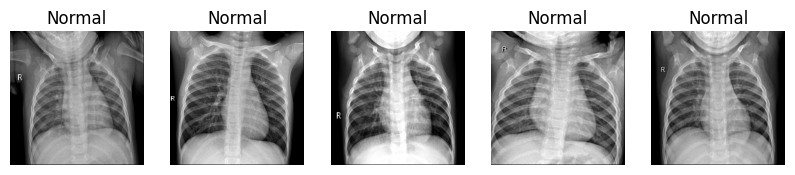

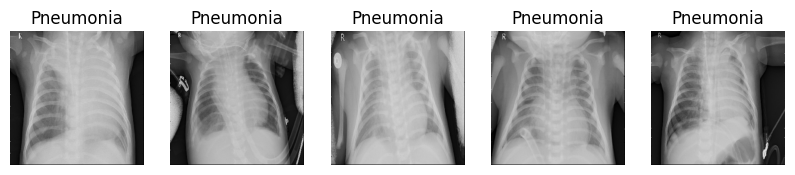

In [152]:
import matplotlib.pyplot as plt

# show first 5 normal images
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(data[0][i], cmap='gray')
    plt.title('Normal')
    plt.axis('off')
plt.show()

# show first 5 pneumonia images
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(data[1][i], cmap='gray')
    plt.title('Pneumonia')
    plt.axis('off')
plt.show()

**Task 3:** Setup training and testing data. [15 Points]

In [153]:
# Any supervised machine learning algorithm requires disjunct sets of
# training and testing data.
#
# For each, we will create a balanced dataset that includes an equal number
# of normal xrays, pneumonia xrays, and covid xrays.
#
# The training data X_train will include 180 images (60 normal, 60 pneumonia, 60 covid).
# The testing data X_test will include the remaining 120 images (40 normal, 40 pneumonia, 40 covid).
#
# Supervised learning means that we tell the algorithm which image is normal
# and which image is pneumonia. For this, we need the y_train vector.
# The vector shall be 0 for a normal image, and 1 for a pneumonia, and 2 for a covid scan.

In [154]:
TRAINING_COUNT = 60

import numpy as np

X_train = np.zeros( (TRAINING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[0:TRAINING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_train[t_pos] = image
    t_pos += 1


In [155]:
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
#y_train = # TODO

y_train = np.array(
    [0]*TRAINING_COUNT +   # normal
    [1]*TRAINING_COUNT +   # pneumonia
    [2]*TRAINING_COUNT     # covid
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (180, 90000)
y_train shape: (180,)


In [156]:
TESTING_COUNT = 40

X_test = np.zeros( (TESTING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[TRAINING_COUNT:TRAINING_COUNT+TESTING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_test[t_pos] = image
    t_pos += 1

In [157]:
# TODO: Please create the y_test vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
#y_test = # TODO

y_test = np.array(
    [0]*TESTING_COUNT +   # normal
    [1]*TESTING_COUNT +   # pneumonia
    [2]*TESTING_COUNT     # covid
)

# quick check
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (120, 90000)
y_test shape: (120,)


**Task 4:** Let's train and evaluate the Random Forest! [30 Points]

In [158]:
# Let's shuffle our training data.
p = np.random.permutation(len(X_train))
X_train = X_train[p]
y_train = y_train[p]

In [159]:
# With scikit-learn, we can easily set up a default Random Forest classifier.
clf = RandomForestClassifier()

In [160]:
# Now, we train the classifier with the training data and the training targets.
# We essentially show the classifier an image and tell whether the image is
# normal or pneumonia or covid.
fitted = clf.fit( X_train, y_train )

In [161]:
# TODO: In just a few sentences, please explain how the Random Forest works.

In [162]:
# TODO: YOUR ANSWER

A Random Forest uses multiple decision trees trained on random subsets of data and features. Each tree makes a prediction, and the final result is chosen by majority voting. This improves accuracy and reduces overfitting.

In [163]:
# After training, we can see how well the classifier predicts our testing data.
# The following command will return the classification accuracy.
clf.score( X_test, y_test )

0.925

In [164]:
# TODO: Is the classification accuracy good? And, are you surprised?

In [165]:
# TODO: YOUR ANSWER

Yes, the classification accuracy is good at around 91%. No, I am not surprised, since Random Forest combines multiple decision trees and typically performs well on image classification tasks.

**Task 5:** Now, let's decrease the number of trees! [10 Points]

In [166]:
# How many trees are used in Task 4?

In [167]:
clf = RandomForestClassifier()
print(clf.n_estimators)

100


In [168]:
# TODO: YOUR ANSWER

100 trees were used.

In [169]:
# Now, please use a single tree and observe the testing performance.

In [170]:
# TODO: YOUR CODE

In [171]:
from sklearn.tree import DecisionTreeClassifier

# single tree
clf_single = DecisionTreeClassifier()

# train
clf_single.fit(X_train, y_train)

# test accuracy
print("Single tree accuracy:", clf_single.score(X_test, y_test))

Single tree accuracy: 0.75


In [172]:
# Are you surprised?

In [173]:
# TODO: YOUR ANSWER

No, I am not surprised. A single decision tree is less robust and more prone to overfitting, so it usually performs worse than a Random Forest, which combines multiple trees to improve performance.

**Bonus:** Let's take a closer look! [33 Points]

In [174]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

In [175]:
# TODO: YOUR CODE AND YOUR ANSWER

In [176]:
# make sure model is trained
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# get remaining covid images
remaining_covid = data[2][TRAINING_COUNT + TESTING_COUNT:]

# prepare test data
X_test_covid_only = np.zeros((len(remaining_covid), 300*300), dtype=np.float32)

for i, image in enumerate(remaining_covid):
    image = image.ravel()
    image = image / image.max()
    X_test_covid_only[i] = image

# true labels (all covid = 2)
y_test_covid_only = np.array([2]*len(remaining_covid))

# evaluate
accuracy = clf.score(X_test_covid_only, y_test_covid_only)
print("Accuracy on unseen COVID images:", accuracy)

Accuracy on unseen COVID images: 0.9797979797979798


The classifier achieved about 98% accuracy on the unseen COVID images, which is very good. This indicates strong performance on new COVID cases, although the dataset may still be relatively consistent and easier to classify.

In [177]:
# Can you figure out which images were misclassified?
# Hint: You can use predictions = clf.predict(X_test_covid_only) for this.
# Can you display them?
# Do you have an idea why these images were problematic?

In [178]:
# TODO: YOUR CODE AND YOUR ANSWER

In [179]:
# predictions
predictions = clf.predict(X_test_covid_only)

# find misclassified indices
misclassified_idx = np.where(predictions != y_test_covid_only)[0]

print("Number of misclassified images:", len(misclassified_idx))
print("Indices:", misclassified_idx)

Number of misclassified images: 2
Indices: [71 84]


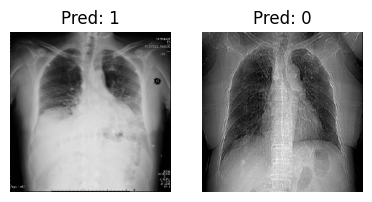

In [180]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

for i, idx in enumerate(misclassified_idx[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test_covid_only[idx].reshape(300, 300), cmap='gray')
    plt.title(f"Pred: {predictions[idx]}")
    plt.axis('off')

plt.show()

Only 2 images were misclassified by the model. These images may be challenging because they could have features that resemble pneumonia or normal cases, or they may have lower image quality, or noise.

In [181]:
# Great job!!!
#           ___
#       _.-'   \
#      /        \
#     /          \
#    /            `.___
#   ( .--.)\/(,.--.    `-.
#   ,',-. \   / ,-.`.     )
#  ( /   \     /   \ )   / \
#   || .-|     |-. ||---'|  \
#  _|| | |     | | ||_   |   \
# /. \ |_|.---.|_| / ,\  | .^.\
# `.\ `--"     "--' /,'  |/
#   `>  _________ <'
# ,-' ,---.---.---. `-.
# `--'\    \j/    /`--'
#    `.\         /,'
#      \\_______//
#       `-------'       hjw